Project 2 - Hidden Markov Models

Brodye Stevens and Jeremy Wiening

Code and Report are mixed together with explanations/analysis of each block. Each area of code is also labeled with its matching Task section (6.1 - 6.5)

---------------------------------------------------------

Introduction:

The objective of this project is to implement a continuous-emission Hidden Markov Model (HMM) to perform phoneme recognition. The model is trained and evaluted on a random split of the CMU ARCTIC dataset.

State Space and Observation Model:

State Space ($S$): The hidden state space consists of $K=40$ discrete classes. This represents a 39-phoneme ARPAbet set plus a dedicated silence/pause class ($pau$). To adhere to this, non-standard phonemes present in the raw data were assigned to their nearest acoustic neighbors. For example, the unstressed vowels $ax$ and $ix$ were mapped to $ah$ and $ih$ respectfully. There shouldn't be any of these phonemes present since directions stated only the 40 phonemes, but this was added just in case.

Observation Model ($O$): The acoustic observations are 39-dimension feature vectors which represent individual speech frames. Each vector consists of 13 Mel-Frequency Cepstral Coefficients (MFCCs), along with their delta ($\Delta$) and double-delta ($\Delta\Delta$) derivatives.

Distributions:

The HMM is fully defined by the parameter set $\lambda=(\pi,A,B)$:

Initial State Distribution ($\pi$): A $K$-dimensional vector where $$\pi_i=P(X_1=s_i)$$ represents the prior probability of the sequence starting in state $i$.


Transition Matrix ($A$): A $K \times K$ stochastic matrix where $$a_{ij}=P(X_{t+1}=s_j | X_t=s_i)$$ represents the probability of transitioning from state $i$ to state $j$


Emission Distribution ($B$): Because the observations are continuous 39-dimensional vectors, the emission probability for each state $j$ is modeled using a single Multivariate Gaussian Distribution, parameterized by a mean vector $\mu_j$ and a full covariance matrix $\Sigma_j$.

Multivariate Gaussian Distribution Equation:

$$b_j(O_t)=\mathcal{N}(O_t | \mu_j,\Sigma_j)=\frac{1}{\sqrt{(2\pi)^D|\Sigma_j|}}\exp\left(-\frac{1}{2}(O_t-\mu_t)^T\Sigma^{-1}_j(O_t-\mu_j)\right)$$

where $D=39$

Data Preparation:

The provided CMU ARCTIC dataset consists of pre-extracted $.npy$ feature matrices and corresponding $.lab$ transcription files containing time-stamped phonemes. The feature extraction phase utilized a 25ms overlapping window shifted by 10ms to generate the MFCCs.

Because the 25ms windowing was handled during signal processing, the alignment algorithm only required the 10ms frame shift to synchronize the text labels with the observation rows. Time boundaries in the $.lab$ files were divided by $0.01$ seconds to assign a discrete phoneme to each 10ms frame, establishing a mapping between $X_{1:T}$ and $O_{1:T}$ for the supervised training

6.1 - Data Preparation

In [ ]:
import os
import numpy as np

DATA_DIRECTORY = "data\out"
LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"
TRAIN_FILE = os.path.join(DATA_DIRECTORY, "train.txt")
VAL_FILE = os.path.join(DATA_DIRECTORY, "val.txt")
TEST_FILE = os.path.join(DATA_DIRECTORY, "test.txt")

def get_basenames(file_path):
    with open(file_path, 'r') as f:
        basenames = [line.strip() for line in f.readlines()]
    return basenames

train_basenames = get_basenames(TRAIN_FILE)
val_basenames = get_basenames(VAL_FILE)
test_basenames = get_basenames(TEST_FILE)

print(f"Loaded {len(train_basenames)} training utterances.")
print(f"Loaded {len(val_basenames)} validation utterances.")
print(f"Loaded {len(test_basenames)} test utterances.")

6.1 Cont. - Phoneme Mapping and Frame Alignment

In [ ]:
import numpy as np

PHONEMES = [
    'pau', 
    'aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'eh', 'er', 'ey', 'ih', 'iy', 'ow', 'oy', 'uh', 'uw', 
    'b', 'ch', 'd', 'dh', 'f', 'g', 'hh', 'jh', 'k', 'l', 'm', 'n', 'ng', 'p', 'r', 's', 'sh', 't', 'th', 'v', 'w', 'y', 'z', 'zh'
]

phoneme_to_id = {p: i for i, p in enumerate(PHONEMES)}
id_to_phoneme = {i: p for p, i in phoneme_to_id.items()}
K = len(PHONEMES)
print(f"Number of unique phonemes: {K}")

def align_frames(lab_path, num_frames, frame_shift=0.01):
    labels = np.zeros(num_frames, dtype=int)
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, ph = parts
                start_frame = int(float(start) / frame_shift)
                end_frame = int(float(end) / frame_shift)
                
                # Fold the edge cases into our standard 40-phoneme list
                if ph == 'ax': 
                    ph = 'ah'
                elif ph == 'ix': 
                    ph = 'ih'
                elif ph == 'dx':
                    ph = 'd'
                
                # Assign the ID if it is in our dictionary
                if ph in phoneme_to_id:
                    labels[start_frame:min(end_frame, num_frames)] = phoneme_to_id[ph]
                    
    return labels

6.2 - Supervised Parameter Estimation

In [ ]:
# Initialize parameters for the model
pi = np.zeros(K)  # Initial state probabilities
A = np.zeros((K, K))  # Transition probabilities
obs_by_state = {i: [] for i in range(K)}  # Observations grouped by state

print("Processing training files to estimate HMM parameters")

for basename in train_basenames:
    feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
    label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")

    obs = np.load(feature_path)  
    T = len(obs)

    states = align_frames(label_path, T)  

    pi[states[0]] += 1  
    for t in range(T - 1):
        A[states[t], states[t + 1]] += 1
    
    for t in range(T):
        obs_by_state[states[t]].append(obs[t])
    
# Normalize to get probabilities
pi_sum = np.sum(pi)
if pi_sum > 0:
    pi /= pi_sum

# Avoid division by zero for transition probabilities
row_sums = A.sum(axis=1, keepdims=True)
A = np.divide(A, row_sums, out=np.zeros_like(A), where=row_sums != 0)

# Compute Gaussian parameters for each state
D = 39
means = np.zeros((K, D))
covs = np.zeros((K, D, D))
# Add regularization term to prevent singular matrix
reg_term = 1e-5 * np.eye(D)

for i in range(K):
    data = np.array(obs_by_state[i])
    if len(data) > 0:
        means[i] = np.mean(data, axis=0) 
        # rowvar=False because rows are observations, columns are variables [cite: 116]
        covs[i] = np.cov(data, rowvar=False) + reg_term 
    else:
        covs[i] = reg_term

print("Finished estimating HMM parameters")

Numerical Stability and Testing:

Because this process involves multiplying many small probabilities hundreds of times, using standard floating-point variables quickly underflow to zero. To make sure the system is stable, we use log-space calculations. The initial probabilities and transition matrices are transformed using $\log(\max(\cdot ,10^{-100}))$ to prevent $\log(0)$ errors

During the Forward Filtering algorithm, calculating the marginal probabilities requires addition of probabilities. To do this, we had to use a log-sum-exp equation $$\log\sum\exp(x_i)=max(x)+\log\sum\exp(x_i-max(x))$$

A common point of failure in a continuous HMM like this is singular covariance matrices that result from states with sparse or highly correlated data. To ensure that all matrices $\Sigma_j$ remain invertible, a small diagonal regularization term ($\epsilon I$, where $\epsilon=10^{-5}$) was added during parameter estimation

Log-PDF Function

In [5]:
def log_multivariate_normal_pdf(x, mean, cov):
    D = len(mean)
    sign, logdet = np.linalg.slogdet(cov)
    diff = x - mean
    inv_cov_dot_diff = np.linalg.solve(cov, diff)
    mahalanobis = np.dot(diff, inv_cov_dot_diff)
    return -0.5 * (D * np.log(2 * np.pi) + logdet + mahalanobis)

Algorithmic Improvement:

A naive implementation of the Gaussian log-PDF nested inside the loops of the inference algorithms requires millions of determinant and inverse calculations, which leads to a massive bottleneck.

To optimize the system, a vectorized 'get_emission_ matrix' function is implemented below. This precomputes the inverses ($\Sigma^{-1}_j$) and log-determinants ($log|\Sigma_j|$) once per state. Then it computes the batched Mahalanobis distance for all frames, reducing inference time exponentially

Emission Matrix Function

In [ ]:
def get_emission_matrix(obs, means, covs):
    T, D = obs.shape
    K = len(means)
    emissions = np.zeros((T, K))
    
    # Precompute inverses and determinants ONCE per state
    inv_covs = np.linalg.inv(covs)
    sign, log_dets = np.linalg.slogdet(covs)
    
    for i in range(K):
        # Subtract mean from all frames simultaneously. Shape: (T, D)
        diff = obs - means[i] 
        
        # Batched Mahalanobis distance: (x-mu)^T * Sigma^-1 * (x-mu)
        # Multiply diff by inverse covariance. Shape: (T, D)
        left_term = np.dot(diff, inv_covs[i])
        
        # Element-wise multiply by diff and sum across the features (D). Shape: (T,)
        mahalanobis = np.sum(left_term * diff, axis=1) 
        
        # Apply the log-PDF formula to all frames at once
        emissions[:, i] = -0.5 * (D * np.log(2 * np.pi) + log_dets[i] + mahalanobis)
        
    return emissions

6.3 - Inference Algorithms

Forward Algorithm

This algorithm is used to compute the marginal probability of being in a specific hidden state at a specific time step, given the sequence of observations leading to that point.

The algorithm computes the forward variable $\alpha_t(i)$, hich is the joint probability of observing the partial sequence $O_{1:t}$ and being in state $i$ at time $t$: $$\alpha_t(i)=P(O_1,O_2,...,O_t,X_t=s_i|\lambda)$$

This algorithm works in three steps:

1. Initialization ($t=1$):

The forward probability for the first frame is the product of the initial state probability and the emission probability of the first observation. $$\alpha_1(i)=\pi_i b_i(O_1)\:\text{ for }\:1\le i\le K$$

2. Recursion ($t=2$ to $T$):

For each time step, the probability of being in state $j$ is calculated by taking the sum of probabilities of all possible paths from the previous time step that transitioned into state $j$, multiplied by the probability of emitting the current observation from state $j$.$$\alpha_t(j)=\left(\sum_{i=1}^{K}\alpha_{t-1}(i)a_{ij}\right)b_j(O_t)\:\text{ for }\:1\le j\le K$$

3. Log-Space Implementation:

Because of the underflow problem mentioned before, we utilize the log-probabilities. The multiplication becomes addition, and the summation requires the log-sum-exp equation to keep stability:$$\log\alpha_t(j)=\log b_j(O_t)+\log\sum_{i=1}^{K}\exp(\log\alpha_{t-1}(i)+\log a_{ij})$$ 

To find the most likely state for a specific frame, you select the state with the highest forward probability at time $t$:$$\hat{X}_t=\arg\max_j\alpha_t(j)$$

In [7]:
def forward_algorithm(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    log_alpha = np.zeros((T, K))
    
    # Initialization
    log_alpha[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            x = log_alpha[t-1, :] + log_A[:, j]
            max_x = np.max(x)
            log_sum_trans = max_x + np.log(np.sum(np.exp(x - max_x)))
            log_alpha[t, j] = log_sum_trans + emission_matrix[t, j]
            
    return np.argmax(log_alpha, axis=1)

Viterbi Algorithm

This algorithm finds the most likely joint sequence of hidden states for the entire observation sequence. It tries to maximize the global probability: $$\arg\max_{X_{1:T}}P(X_{1:T}|O_{1:T},\lambda)$$

Viterbi is another dynamic programming algorithm (like Forward Filtering), but it only keeps the maximum instead of the sum over all previous paths. It defines a value $V_t(j)$, which represents the probability of the most likely path ending in state $j$ at time $t$.

We will break the algorithm into its steps, just like Forward Filtering.

1. Initialization ($t=1$):

$$V_1(i)=\pi b_i(O_1)\:\text{ for }\:1\le i \le K$$

A backpointer matrix $B$ is intialized to keep track of the best paths:$$B_1(i)=0$$

2. Recursion ($t=2$ to $T$):

For each state $j$ at time $t$, the algorithm finds the single previous state $i$ that provides the highest transition probability.

$$V_t(j)=\max_{1\le i\le K}(V_{t-1}(i)a_{ij})\cdot b_j(O_t)$$

The state $i$ that maximizes the value is then stored in $B$:$$B_t(j)=\arg\max_{1\le i\le K}(V_{t-1}(i)a_{ij})$$

3. Log-Space Implementation:

Viterbi recursion is very efficient in log-space since it avoids the need sof the log-sum-exp equation. All the operations used become simple additions and $\max ()$ lookups:$$\log V_t(j)=\max_{1\le i\le K}(\log V_{t-1}(i)+\log a_{ij})+\log b_j(O_t)$$

4. Termination and Backtracking:

There is an additional step present in Viterbi that isnt there in Forward Filtering. Once the sequence is fully processed, the algorithm finds the final state with the highest probability:$$X_T^*=\arg\max_{1\le i\le K}V_T(i)$$

It then traces backwards through $B$ to reconstruct the optimal hidden state sequence:$$X_t^*=B_{t+1}(X_{t+1}^*)\:\text{ for }\:t=T-1,T-2,...,1$$

In [8]:
def viterbi_decode(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    v_table = np.zeros((T, K))
    backpointers = np.zeros((T, K), dtype=int)
    
    # Initialization
    v_table[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            trans_probs = v_table[t-1, :] + log_A[:, j]
            best_prev = np.argmax(trans_probs)
            v_table[t, j] = trans_probs[best_prev] + emission_matrix[t, j]
            backpointers[t, j] = best_prev
            
    # Termination & Backtracking
    best_path = np.zeros(T, dtype=int)
    best_path[T-1] = np.argmax(v_table[T-1, :])
    for t in range(T-2, -1, -1):
        best_path[t] = backpointers[t+1, best_path[t+1]]
        
    return best_path

6.4 - Evaluation

In [ ]:
def evaluate_model(basenames, pi, A, means, covs, is_test_set=False):
    total_frames = 0
    viterbi_correct = 0
    forward_correct = 0
    
    # Track confusions
    conf_mat_v = np.zeros((K, K), dtype=int)
    conf_mat_f = np.zeros((K, K), dtype=int)
    
    print(f"Evaluating {len(basenames)} utterances...")
    
    for idx, basename in enumerate(basenames):
        feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
        label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")
        
        obs = np.load(feature_path)
        T = len(obs)
        true_states = align_frames(label_path, T)
        total_frames += T
        
        emissions = get_emission_matrix(obs, means, covs)
        
        viterbi_preds = viterbi_decode(emissions, pi, A)
        forward_preds = forward_algorithm(emissions, pi, A)
        
        viterbi_correct += np.sum(viterbi_preds == true_states)
        forward_correct += np.sum(forward_preds == true_states)
        
        # Populate both matrices for the test set
        if is_test_set:
            for t in range(T):
                conf_mat_v[true_states[t], viterbi_preds[t]] += 1
                conf_mat_f[true_states[t], forward_preds[t]] += 1
                
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1} / {len(basenames)} files...")

    v_acc = viterbi_correct / total_frames
    f_acc = forward_correct / total_frames
    print(f"\nFinal Viterbi Accuracy: {v_acc:.4f}")
    print(f"Final Forward Accuracy: {f_acc:.4f}")
    
    if is_test_set:
        return v_acc, f_acc, conf_mat_v, conf_mat_f
        
    return v_acc, f_acc

print("--- Training Set Evaluation ---")
train_v_acc, train_f_acc = evaluate_model(train_basenames, pi, A, means, covs, is_test_set=False)

print("\n--- Test Set Evaluation ---")
test_v_acc, test_f_acc, conf_mat_v, conf_mat_f = evaluate_model(test_basenames, pi, A, means, covs, is_test_set=True)

Plot Generation

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(14, 12)) # Made slightly larger to fit all labels
    plt.imshow(np.log(conf_matrix + 1), cmap='viridis')
    plt.colorbar(label='Log Frequency')
    plt.title(title, fontsize=16)
    plt.xlabel('Predicted Phoneme', fontsize=12)
    plt.ylabel('True Phoneme', fontsize=12)
    plt.xticks(np.arange(K), PHONEMES, rotation=90)
    plt.yticks(np.arange(K), PHONEMES)

    plt.tight_layout()
    plt.show()

# Plot Viterbi
plot_confusion_matrix(conf_mat_v, 'Phoneme Confusion Matrix (Viterbi)')

# Plot Forward Filtering
plot_confusion_matrix(conf_mat_f, 'Phoneme Confusion Matrix (Forward Filtering)')

Generated Confusion Matrices:

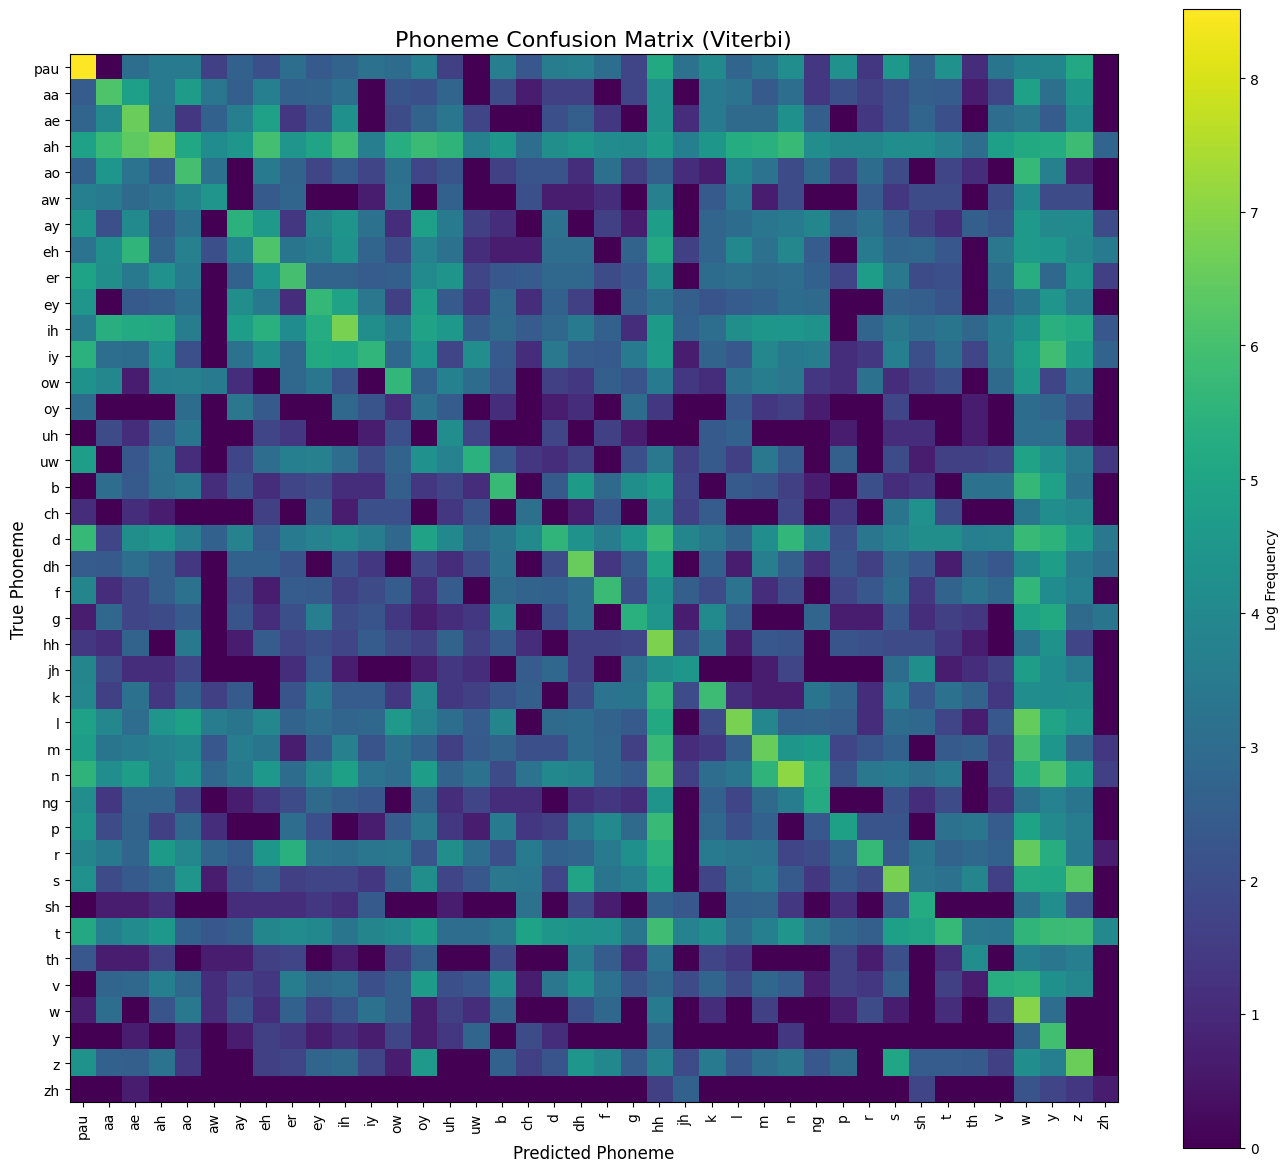

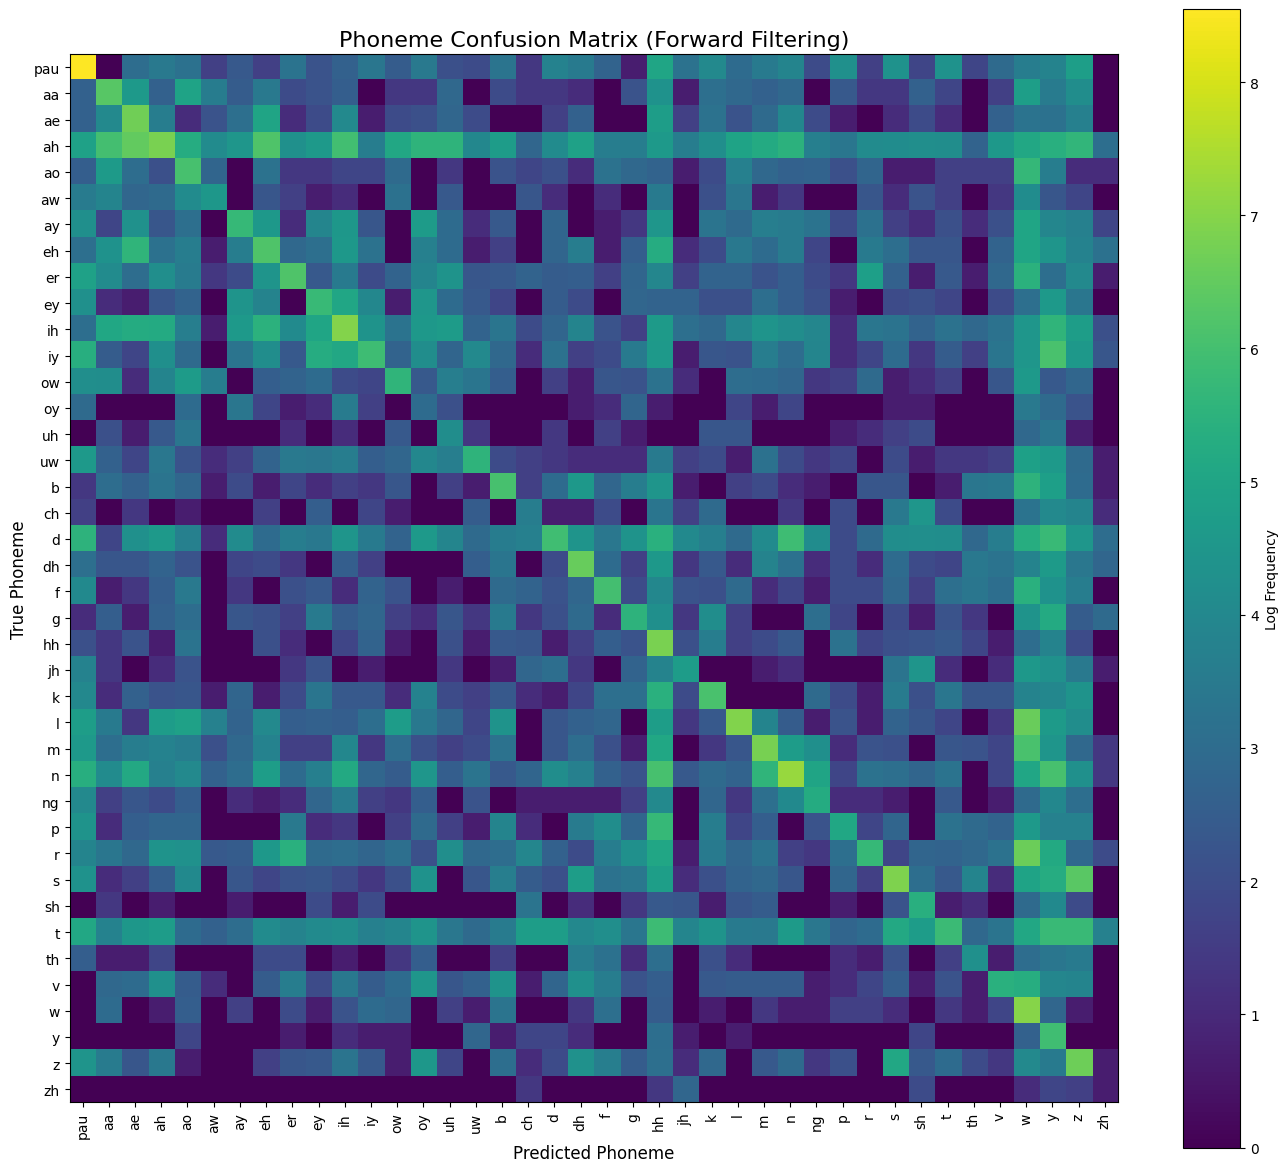

6.5 - Analysis and Discussion

1. How does the accuracy differ between Forward Filtering and Viterbi, and why?

The Forward Filtering algorithm consistently achieved higher accuracy than the Viterbi Decoding algorithm. On the test set, Filtering achieved an accuracy of 33.84%, while Viterbi only got 30.54%. This difference is due to the mathematical designs of each algorithm. Filtering computes the marginal probability of a single state at a specific time step, which means it is deciding the most likely phoneme frame-by-frame. This approach minimizes the frame error rate. On the other hand, Viterby computes the most likely joint sequence of states. It optimizes for th best overall "path" and purposefully selects a locally suboptimal phoneme for a specific frame if it results in a sequence with higher transition probabilities. Because the evaluation metric strictly counts individual correct frames, Filtering scores better.

2. Is the accuracy different between the train and test set? Why?

Yes, the model performs slightly better on the training set than on the testing set. For the Filtering algorithm, training accuracy was 35.82%, while the test accuracy dropped to 33.84%. Likewise, the Viterbi algorithm dropped from 32.47% to 30.54%. This slight degradation is an indication of mild overfitting in the model. The model's emission parameters were estimated from the utterances in the training set, which means the Gaussian distributions slightly memorized the specific details of the audio files. When the model evaluates the test data, the new acoustic features do not perfectly line up with the training files, so there is a slight drop in performance. Since the decrease is minor, the overfitting is not a dominant feature in the training set's performance.

3. Which phonemes are most often confused? 

Based off the bright clusters of squares away from the diagonal of the matrices, the model has a few groups of phonemes that are frequently confused.

First, vowels with similar sounds are often confused by the model. For example, 'aa' is mistaken for 'ao' and 'ah', while 'ih' has overlap with 'iy' and 'eh'.

Next, 'm', 'n', and 'ng' have significant cross-confusion, likely because they have similar nasal sounds.

Next, the model frequently mistakes quieter phonemes, such as 'f', 'th', and 'hh' as 'pau'. The low volume of these phonemes makes them difficult for the model to distiguish from ambient noise.

Finally, pairs that have the same mouth position but slightly different sounds, like 's' and 'z', show noticable overlap. This indicates that the model sometimes fails to detect voicing.

4. For which phonemes is the model better/worse at predicting them correctly?

The model is excellent at predicting 'pau' (silence), representeed by the bright yellow square at the top left corner of the matrix. Silence has a lack of energy that forms a tight cluster. The model is also very accurate for distinct phonemes such as 's', 'l', and 'n'; as well as extreme vowels like 'iy' and 'ah'

The model performs very poorly on 'zh', 'oy', 'uh', 'ch', and 'jh', which are all quite dark on their diagonal position. This is because these phonemes are either relatively rare in the dataset, such as 'zh', or are dynamic in how they are sounded out, such as 'ch'. The dynamic phonemes are difficult to capture with a single Gaussian curve.

5. Generally, how well does the approach work?

The approach works well, with close to the expected accuracy percentages and most phonemes have a brighter diagonal than horizontal which means that they are correctly predicted more often than not, aside from the few that are especially poor.

However, the approach of the model is limited by its architecture. The model struggles to capture the high variance of human pronunciation with only a single multivariate Gaussian and hidden state. Furthermore, relying solely on acoustic features and transition probabilities without a robust language model to back it up means that the system frequently predicts sequences that are verbally plausible but linguistically impossible.

Conclusion

Overall, the Forward Filtering and Viterbi algorithms worked as well as expected at sorting through and correctly determining the phonemes used in both the train and test sets of utterances. The entire phoneme set was found throughout the sets of utterances, and a matrix was compiled for each of the two algorithms as shown above. The EM/Baum-Welch algorithms were not added or attempted to be added.